## **Trabajo Práctico 2- Contenido Nutricional de la Canasta Básica**

**Grupo** : Susano y Valentín

**Integrantes** :

*   Ibarra, Abril Magalí   LU: 945/23
*   Dominguez, Rocio Julieta  LU:798/22


              
           
               

En este trábajo práctico abordamos el estudio del contenido nutricional de la canasta básica de los argentinos(*CBA*).
Para ello, aplicamos los conocimientos adquiridos de reducción de la dimensionalidad, clasificación, espacios vectoriales, mìnimos cuadrados, entre otros.

------
#**Objetivos**

* Analizar la evolución de los precios de los alimentos en la canasta básica.
* Evaluar los cambios en el contenido nutricional de los alimentos.
* Determinar si existe alguna relación entre los precios y el contenido nutricional.
------
Esta notebook se encuentra organizada en secciones, las cuales se corresponden con las consignas dadas


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D



##***Preprocesamiento de los datos:***

Cargamos el archivo .csv que contiene la información de la tabla nutricional como un dataframe de Pandas.
Posteriormente, estandarizamos los datos para poder hacer un análisis preciso y eficiente.

In [2]:
def estandarizar_tabla_nutricional(tabla_nutricional):
    """
    Dado un dataframe, llena los valores nulos con 0 y convierte los valores en
    miligramos a gramos.
    """
    tabla_nutricional = tabla_nutricional.fillna(0)
    columnas_mg = [col for col in tabla_nutricional.columns if 'mg' in col]
    tabla_nutricional[columnas_mg] /= 1000
    tabla_nutricional.columns = tabla_nutricional.columns.str.replace('mg', 'gr', regex=True)
    return tabla_nutricional

In [3]:

#Creamos dataframes con los datos en formato csv
tabla_nutricional = pd.read_csv('tabla_nutricional.csv',delimiter= ';')
consumidores_libres = pd.read_csv('consumidores_libres.csv' ,delimiter = ';')

#Estandarizamos la tabla
tabla_nutricional = estandarizar_tabla_nutricional(tabla_nutricional)

print('Tabla Nutricional')
tabla_nutricional


Tabla Nutricional


,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr)
0,Leche fluida entera,270.00,12.420,8.370,7.830,0.153900,0.28350,0.000189,0.00,4.990,2.190,0.520,0.00
1,Leche entera en polvo,11.00,4.510,2.840,2.730,0.044440,0.09900,0.000060,0.00,1.620,0.770,0.060,0.00
2,Yogurt,19.00,2.450,0.510,0.490,0.007990,0.01767,0.000005,0.00,0.320,0.140,0.014,0.00
3,Queso crema,1.66,0.060,0.100,0.370,0.001230,0.00093,0.000000,0.00,0.360,0.110,0.010,0.00
4,Queso cuartirolo,3.66,0.060,0.770,0.800,0.020840,0.01654,0.000000,0.00,0.760,0.210,0.020,0.00
5,Queso rallar,1.66,0.060,0.550,0.450,0.020420,0.01578,0.000000,0.00,0.360,0.110,0.008,0.00
6,Huevo,16.00,0.000,1.920,1.890,0.021600,0.00896,0.000400,0.00,0.510,0.720,0.460,0.00
7,Asado,50.00,0.000,9.300,7.500,0.033000,0.00750,0.001120,0.00,2.930,3.270,0.189,0.00
8,Paleta,15.00,0.000,3.000,1.500,0.009900,0.00180,0.000340,0.00,0.880,0.980,0.056,0.00
9,Hueso c/carne,15.00,0.000,3.000,1.500,0.009900,0.00180,0.000340,0.00,0.880,0.980,0.056,0.00


In [4]:
print('Consumidores Libres')
consumidores_libres.head(3)

Consumidores Libres


,PRODUCTOS,Cantidad,31/12/2023,31/1/2024,29/2/2024,31/3/2024,30/4/2024
0,ACEITE COCINERO GIRASOL,1500,2500.0,3100.0,3450.0,3600.0,3700.0
1,ARROZ GRANO FINO,1000,1650.0,2300.0,2800.0,3100.0,3550.0
2,AZUCAR LEDESMA,1000,1990.0,2050.0,2050.0,2100.0,2100.0


Posteriormente desarrollamos una función para que dado un dataframe, decida si los valores nutricionales de los elementos de una dieta, se encuentran dentro de los margenes establecidos por la OMS.

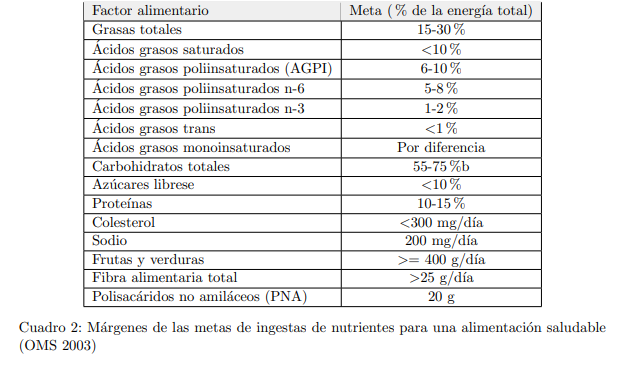

Para realizar las comparaciones, se tuvieron en cuenta las siguientes relaciones, tal cual destca la tesis:

* Proteínas: 4kcal/g
* Grasas: 9kcal/g
* Carbohidratos: 4kcal/g


In [5]:
def evaluarCumplimiento_dieta_margenes(data):
    """
    Evalúa si las cantidades de los principales elementos de la dieta, proteínas,
    carbohidratos, grasas, sodio, fibra, frutas y verduras, cumple los márgenes
    de ingesta de la OMS (2750kcal/Dia).

    Retorna una tupla, donde el primer elemetno es si cumple o no con los márgenes y el segundo es un dataframe con los valores.

    """
    #Extraemos manualmente las frutas y verduras en la tabla nutricional
    frutas_verduras_lista = ['Acelga', 'Zanahoria', 'Tomate', 'Lechuga', 'Cebolla', 'Zapallo', 'Manzana', 'Naranja', 'Mandarina', 'pera', 'Banana', 'Papa', 'Batata']

    #Calculamos las cantidades totales
    proteinas = data['Proteinas (gr)'].sum()
    carbohidratos = data['HC (gr)'].sum()
    grasas = data['Grasas (gr)'].sum()
    sodio = data['Na (gr)'].sum()
    fibra = data['Fibra (gr)'].sum()
    frutas_verduras = data[data['Alimento'].isin(frutas_verduras_lista)]['Cantidad (gr/ml)'].sum()

    #Comparamos las cantidades totales con los márgenes
    proteinas_cumple = 10 <= ((proteinas*4)/2750)*100 <= 15
    carbohidratos_cumple = 55 <= ((carbohidratos*4)/2750)*100 <=75
    grasas_cumple = 15 <= ((grasas*9)/2750)*100 <= 30
    sodio_cumple = sodio <= 2
    fibra_cumple = fibra > 25
    frutas_verduras_cumple = frutas_verduras >= 400
    data = {
       'Nutriente': ['proteinas', 'carbohidratos', 'grasas', 'sodio', 'fibra', 'frutas y verduras'],
       'Cumple': [proteinas_cumple, carbohidratos_cumple, grasas_cumple, sodio_cumple, fibra_cumple, frutas_verduras_cumple],
       'Valor': [(((proteinas*4)/2750)*100).round(2), (((carbohidratos*4)/2750)*100).round(2),
                 (((grasas*9)/2750)*100).round(2), sodio.round(2), fibra, frutas_verduras],
       'Unidad':['Calorias','Calorias','Calorias','gr','gr/dia','gr']
   }

    df = pd.DataFrame(data)
    cumple = proteinas_cumple and carbohidratos_cumple and grasas_cumple and sodio_cumple and fibra_cumple and frutas_verduras_cumple

    return 'Cumple los márgenes' if cumple else 'No cumple los márgenes', df

In [6]:
#Verificamos si la CBA cumple los márgenes de la OMS
print(evaluarCumplimiento_dieta_margenes(tabla_nutricional)[0])
df = evaluarCumplimiento_dieta_margenes(tabla_nutricional)[1]
#Ahora mostramos el datframe con la informacion de los nutrientes y sus valores
df

No cumple los márgenes


,Nutriente,Cumple,Valor,Unidad
0,proteinas,False,16.35,Calorias
1,carbohidratos,True,59.67,Calorias
2,grasas,True,25.17,Calorias
3,sodio,False,3.34,gr
4,fibra,False,21.26,gr/dia
5,frutas y verduras,True,650.00,gr


Vemos que tal cual indica la tésis dada, la tabla proporcionada no cumple con los márgenes de ingesta de la OMS y podemos apreciar como sus valores se salen de los márgenes establecidos.

------



###**Análisis en Componentes Principales**
**¿Qué es la Descomposición en Valores Singulares (SVD)?**

La Descomposición en Valores Singulares es una técnica que descompone una matriz $A$ de tamaño $m \times n$ en tres matrices: una matriz unitaria $U$, una matriz diagonal $\Sigma$ y la matriz unitaria $V^T$:

$A = U \Sigma V^T$

- **$U$**: Es una matriz unitaria de tamaño $m \times m$ cuyas columnas son los vectores singulares izquierdos de $A$.
- **$\Sigma$**: Es una matriz diagonal de tamaño $m \times n$ con los valores singulares de $A$ en la diagonal.
- **$V^T$**: Es la transpuesta de una matriz unitaria $V$ de tamaño $n \times n$ cuyas columnas son los vectores singulares derechos de $A$.

Una de las aplicaciones más comunes de SVD es en el *Análisis de Componentes Principales (PCA)*, donde se utiliza para identificar las direcciones principales en las que varían los datos y para reducir su dimensionalidad.

-----

En nuestro análisis de la canasta básica, utilizamos la SVD para realizar PCA sobre la tabla de valores nutricionales de los alimentos. Esto nos permitirá:

1. **Reducir la Dimensionalidad de los Datos**: Proyectar los datos nutricionales en un subespacio de menor dimensión, conservando la mayor cantidad de información posible,facilitando el análisis de los mismos.
2. **Visualizar los Datos**: Facilitar la visualización y el análisis de las características nutricionales de los alimentos en un espacio bidimensional.
3. **Identificar Patrones y Agrupaciones**: Detectar clusters y patrones en los datos nutricionales, ayudándonos a entender mejor las similitudes y diferencias entre los alimentos.

### Pasos del Análisis

1. **Preparación de los Datos**: Normalización y limpieza de los datos nutricionales.
2. **Cálculo de la SVD**: Descomposición de la matriz de datos nutricionales en sus componentes $U$, $\Sigma$ y $V^T$.
3. **Proyección en el Subespacio**: Uso de los vectores singulares derechos para proyectar los datos en el subespacio generado por los vectores singulares izquierdos.
4. **Visualización y Análisis**: Gráfico de los datos proyectados en el espacio reducido y análisis de los patrones y agrupaciones observadas.
-----

Para ello, realizamos la siguiente función:


Obtenemos los componentes principales para realizar la proyección en el subespacio generado junto con la variabilidad explicada obtenida al proyectar en tres componentes.

--------------
La varianza explicada es una medida de dispersion, con la cual pretendemos representar la variabilidad de una serie de datos con respecto a su media.Viendo que proporción de la totalidad de los datos es representada.

In [7]:
def componentes_principalesSVD(X, k):
    """
    Dada una matriz X, computa su factorización SVD y retorna la proyección
    sobre el subespacio generado por los primeros k vectores singulares izquierdos
    de X y la martriz truncada de la SVD Vt_k.
    """
    # Centramos los vectores columna (características) según sus promedios
    n, d = X.shape
    m = np.mean(X, axis=0)
    X = X - m

    # Obtenemos los autovalores y autovectores de la matriz de covarianza
    MCov = np.dot(X.T, X) / X.shape[0]
    avals, avecs = np.linalg.eigh(MCov)
    # Ordenamos los autovalores y autovectores
    indices_ordenados = np.argsort(-avals)
    avals = avals[indices_ordenados]
    avecs = avecs[:, indices_ordenados]
    # Seleccionamos los primeros k vectores singulares derechos de X
    Vt_k = avecs[:, :k]
    # Proyectamos los datos en el subespacio generado por los primeros k vectores singulares izquierdos
    X_proyectado = X @ Vt_k

    # Calculamos la proporción de la varianza explicada
    var_explicada = avals[:k] / np.sum(avals)
    var_explicada_acumulada = np.cumsum(var_explicada)

    return X_proyectado, Vt_k, var_explicada, var_explicada_acumulada



In [8]:
# Reducimos la dimensionalidad de los datos (X) mediante PCA
matriz_nutricional = tabla_nutricional.iloc[:, 1:].values

X_proyectado, Vt_3, var_explicada, var_explicada_acumulada = componentes_principalesSVD(matriz_nutricional, 3) # Proyección en 3 componentes

# Imprimimos la proporción de la varianza explicada
print(f'Proporción de la varianza explicada por cada una de las 3 primeras componentes principales: {var_explicada * 100}')
print(f'Proporción de la varianza explicada acumulada: {var_explicada_acumulada * 100}')


Proporción de la varianza explicada por cada una de las 3 primeras componentes principales: [90.94402696  7.10339693  0.89723063]
Proporción de la varianza explicada acumulada: [90.94402696 98.0474239  98.94465453]


Procedamos a analizar las proporciones obtenidas de varibilidad explicada por componente y acumulada.
### **Variabilidad Explicada por Componente**
* **Primera componente principal (90.94402696%):** La primera componente principal captura aproximadamente el 90.94% de la varianza total en los datos. Esto nos dice que casi toda la información relevante en los datos originales se puede representar a lo largo de esta dirección.
* **Segunda componente principal (7.10339693%)**: La segunda componente principal captura un adicional 7.10% de la varianza total. Esto sugiere que, después de la primera componente principal, hay todavía una cantidad significativa de variabilidad que no ha sido capturada.
* **Tercera componente principal (0.89723063%)**: La tercera componente principal captura solo el 0.90% de la varianza total, lo cual es resulta basatnte pequeño. Esto sugiere que las componentes principales adicionales después de las dos primeras no añaden mucho valor en términos de capturar la variabilidad en los datos.

### **Variabilidad Explicada acumulada**
* **Primera y Segunda Componentes:** La varianza explicada acumulada por las dos primeras componentes es 98.0474239%. Esto significa que al usar solo las dos primeras componentes principales, puedes capturar aproximadamente el 98.05% de la varianza total de los datos.
* **Primera, Segunda y Tercera Componentes:** La varianza explicada acumulada por las tres primeras componentes es 98.94465453%. Al agregar la tercera componente principal, se es capturado 0.90% adicional, llevando el total a aproximadamente 98.94%.

Ahora, procedemos a graficar la proyección en un espacio de dimensionalidad reducida, tridimensional.

In [9]:
def graficarProyeccion3D(X_proyectado, alimentos, titulo, n_clusters=4):
    """
    Grafica los alimentos como puntos en el subespacio generado por las 3
    componentes principales, coloreando los puntos según sus clusters.
    """
    # Aplicamos KMeans para encontrar clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X_proyectado)
    labels = kmeans.labels_

    # Creamos un  DataFrame con el número de cluster y alimento
    df_clusters = pd.DataFrame({
        'Alimento': alimentos,
        'Número de Cluster': labels,
    })

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_proyectado[:, 0], X_proyectado[:, 1], X_proyectado[:, 2], c=labels, cmap='viridis', alpha=0.5)
    ax.set_xlabel('Componente Principal 1')
    ax.set_ylabel('Componente Principal 2')
    ax.set_zlabel('Componente Principal 3')
    ax.set_title(titulo)
    fig.colorbar(scatter)
    plt.show()

    return df_clusters

Además, agrupamos en clusters aquellos datos de valores similares para un posterior análisis.

Veamos el gráfico tridimensional obtenido al reducir la dimensión

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


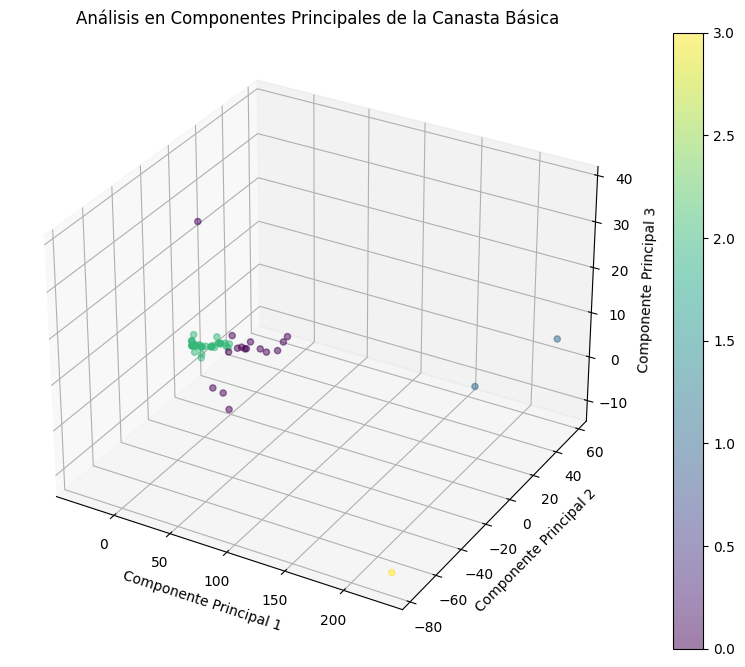

In [10]:

# Graficamos la proyección con los clusters y obtenemos el DataFrame de clusters
alimentos = tabla_nutricional['Alimento'].values

df_clusters = graficarProyeccion3D(X_proyectado, alimentos, 'Análisis en Componentes Principales de la Canasta Básica') #guardamos un dataframe coon la informacion de los clusters


In [11]:
df_clusters.head(3)

,Alimento,Número de Cluster
0,Leche fluida entera,1
1,Leche entera en polvo,2
2,Yogurt,2


Ahora procedamos a analizar los clústeres obtenidos.

Para visualizar qué valores nutricionales destacan en cada clúster, en el siguiente gráfico comparamos el promedio de macronutrientes por clúster:

In [12]:
def graficos_cluster(df_clusters):
    """
    Genera gráficos de barras para visualizar el promedio de macronutrientes
    (HC, proteínas, azúcares libres, grasas, y fibra) por cada grupo de
    alimentos agrupados en cuatro clusters.

    Parámetros:Ninguno.

    Retorna: Muestra gráficos y realiza impresiones en pantalla.
    """

    # Para el grupo 1
    grupo1 = df_clusters[df_clusters['Número de Cluster'] == 0]['Alimento'].tolist()
    grupo1 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo1)]
    grupo1 = grupo1.merge(df_clusters, on='Alimento', how='left')
    cant1 = len(grupo1)

    # Para el grupo 2
    grupo2 = df_clusters[df_clusters['Número de Cluster'] == 1]['Alimento'].tolist()
    grupo2 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo2)]
    grupo2 = grupo2.merge(df_clusters, on='Alimento', how='left')
    cant2 = len(grupo2)

    # Para el grupo 3
    grupo3 = df_clusters[df_clusters['Número de Cluster'] == 2]['Alimento'].tolist()
    grupo3 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo3)]
    grupo3 = grupo3.merge(df_clusters, on='Alimento', how='left')
    cant3 = len(grupo3)


    # Para el grupo 4
    grupo4 = df_clusters[df_clusters['Número de Cluster'] == 3]['Alimento'].tolist()
    grupo4 = tabla_nutricional[tabla_nutricional['Alimento'].isin(grupo4)]
    grupo4 = grupo4.merge(df_clusters, on='Alimento', how='left')
    cant4 = len(grupo4)


    # Lista de macronutrientes
    macronutrientes = ['HC (gr)', 'Proteinas (gr)', 'Azucares Libres (gr)', 'Grasas (gr)', 'Fibra (gr)']

    df_combined = pd.concat([grupo1, grupo2, grupo3, grupo4])

    promedios_grupos = df_combined.groupby('Número de Cluster')[macronutrientes].mean().reset_index()
    promedios_grupos['Número de Cluster'] += 1

    sns.set(style="darkgrid")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)

    # Aplanar los ejes para iterar fácilmente
    axes = axes.flatten()


    for idx, macronutriente in enumerate(macronutrientes):
        sns.barplot(ax=axes[idx], x='Número de Cluster', hue= 'Número de Cluster', y=macronutriente, data=promedios_grupos, palette='viridis', legend=False)
        axes[idx].set_title(f'Promedio de {macronutriente} por Cluster')
        axes[idx].set_xlabel('Número de Cluster')
        axes[idx].set_ylabel(macronutriente)

    # Eliminar el último subgráfico si hay menos de 6
    if len(macronutrientes) < len(axes):
        fig.delaxes(axes[-1])

    # Ajustar el layout para evitar solapamientos
    plt.tight_layout()


    plt.show()
    print(f'cantidad de alimentos cluster 1: {cant1}')
    print(f'cantidad de alimentos cluster 2: {cant2}')
    print(f'cantidad de alimentos cluster 3: {cant3}')
    print(f'cantidad de alimentos cluster 4: {cant4}')
    return grupo1, grupo2,grupo3,grupo4

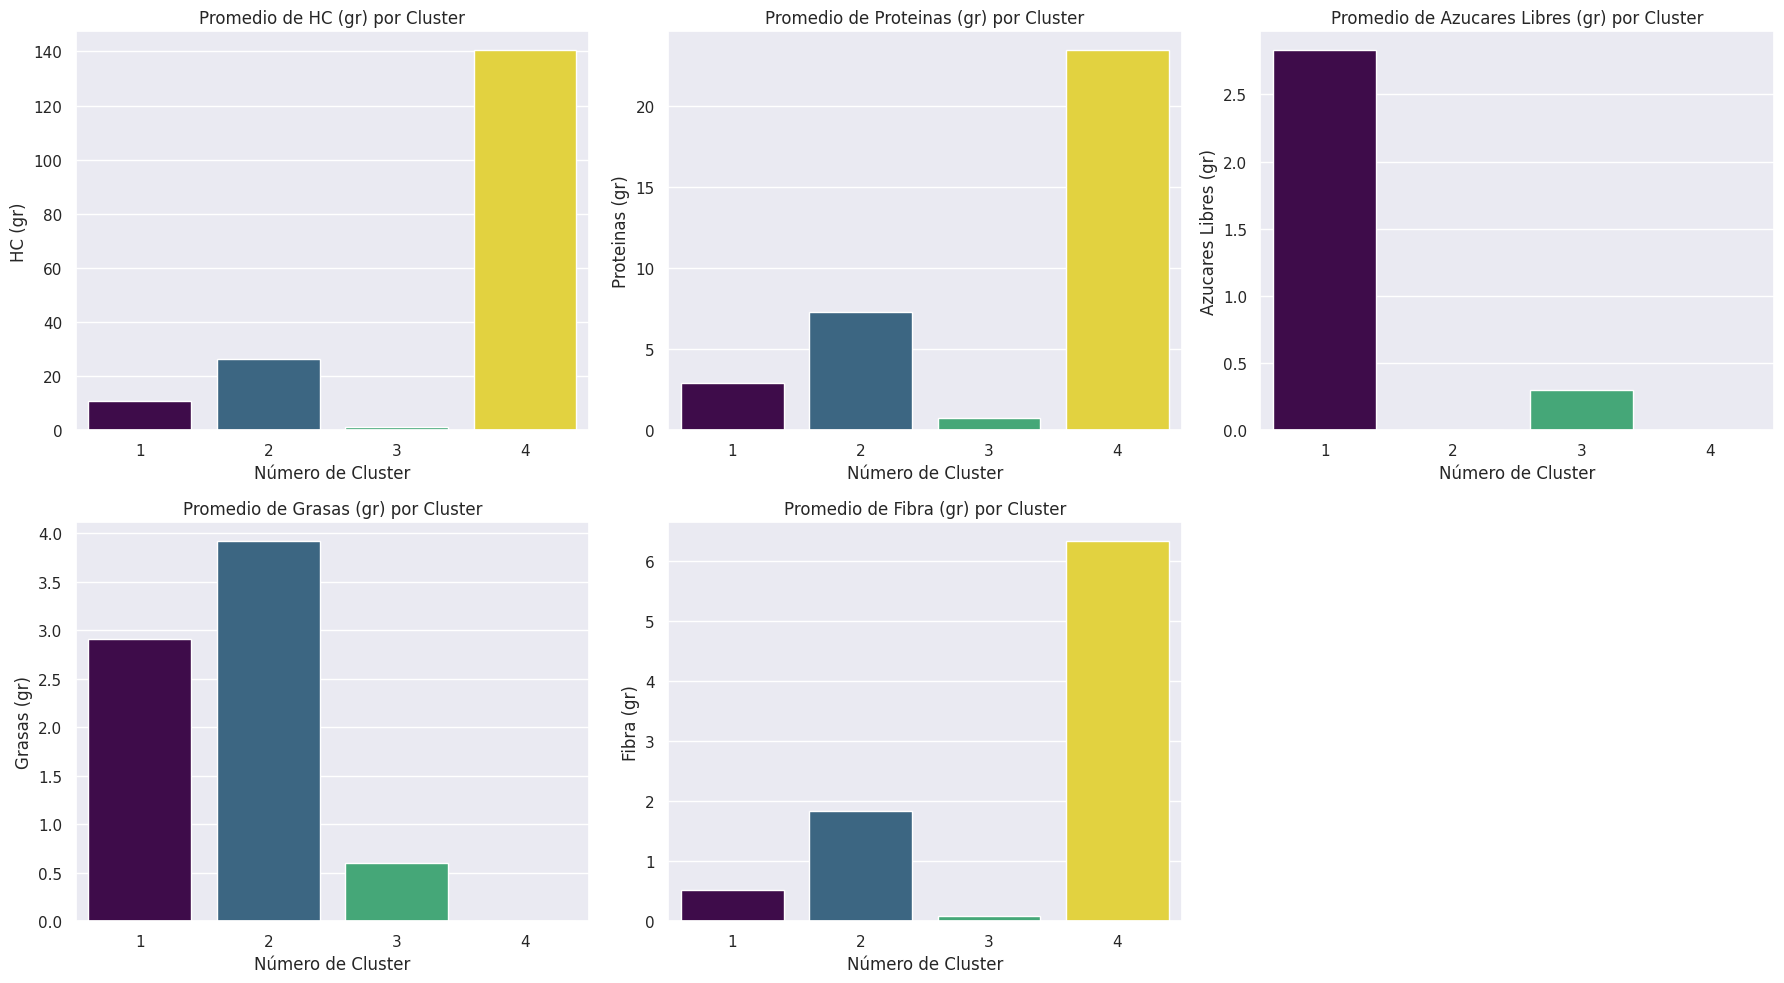

cantidad de alimentos cluster 1: 16
cantidad de alimentos cluster 2: 2
cantidad de alimentos cluster 3: 38
cantidad de alimentos cluster 4: 1


In [13]:
cluster_1,cluster_2,cluster_3,cluster_4 = graficos_cluster(df_clusters)


Observamos que la cantidad de alimentos agrupados en cada clúster no es uniforme, lo que indica que algunos alimentos tienen valores nutricionales significativamente diferentes del resto. Esto ha llevado a que el PCA les asigne un clúster propio, veamos como son los clusters de alimentos.

In [14]:
cluster_1

,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,Asado,50.0,0.00,9.30,7.50,0.03300,0.00750,0.00112,0.00,2.930,3.270,0.189,0.00,0
1,Bola de Lomo,34.0,0.00,7.21,0.48,0.02142,0.00102,0.00118,0.00,1.990,2.200,0.130,0.00,0
2,pollo,63.0,0.00,13.23,2.39,0.04599,0.00756,0.00098,0.00,1.870,2.720,1.430,0.00,0
3,Tomate,69.0,2.83,0.69,0.00,0.00345,0.00621,0.00115,0.00,0.000,0.000,0.000,0.83,0
4,Cebolla,44.0,0.97,0.35,0.00,0.01144,0.01144,0.00025,0.00,0.000,0.000,0.000,0.57,0
5,Manzana,61.0,9.09,0.18,0.00,0.00305,0.00244,0.00031,0.00,0.000,0.000,0.000,0.85,0
6,Naranja,43.0,5.33,0.43,0.00,0.00301,0.00903,0.00015,0.00,0.000,0.000,0.000,0.82,0
7,Mandarina,44.0,5.28,0.44,0.00,0.00308,0.00924,0.00015,0.00,0.000,0.000,0.000,0.84,0
8,Banana,32.0,6.49,0.38,0.00,0.00032,0.00224,0.00013,0.00,0.000,0.000,0.000,0.58,0
9,Arroz,36.0,28.51,2.48,0.00,0.00144,0.00324,0.00025,0.00,0.000,0.000,0.000,0.97,0


In [15]:
cluster_2

,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,Leche fluida entera,270.0,12.42,8.37,7.83,0.15390,0.28350,0.000189,0.0,4.99,2.19,0.52,0.00,1
1,Papa,229.0,40.53,6.18,0.00,0.05496,0.05725,0.001970,0.0,0.00,0.00,0.00,3.66,1


In [16]:
cluster_3

,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,Leche entera en polvo,11.00,4.510,2.840,2.730,0.044440,0.09900,0.000060,0.00,1.620,0.770,0.060,0.00,2
1,Yogurt,19.00,2.450,0.510,0.490,0.007990,0.01767,0.000005,0.00,0.320,0.140,0.014,0.00,2
2,Queso crema,1.66,0.060,0.100,0.370,0.001230,0.00093,0.000000,0.00,0.360,0.110,0.010,0.00,2
3,Queso cuartirolo,3.66,0.060,0.770,0.800,0.020840,0.01654,0.000000,0.00,0.760,0.210,0.020,0.00,2
4,Queso rallar,1.66,0.060,0.550,0.450,0.020420,0.01578,0.000000,0.00,0.360,0.110,0.008,0.00,2
5,Huevo,16.00,0.000,1.920,1.890,0.021600,0.00896,0.000400,0.00,0.510,0.720,0.460,0.00,2
6,Paleta,15.00,0.000,3.000,1.500,0.009900,0.00180,0.000340,0.00,0.880,0.980,0.056,0.00,2
7,Hueso c/carne,15.00,0.000,3.000,1.500,0.009900,0.00180,0.000340,0.00,0.880,0.980,0.056,0.00,2
8,Carne picada,27.00,0.000,5.400,2.700,0.017820,0.00324,0.000600,0.00,1.580,1.770,0.100,0.00,2
9,Higado,9.00,0.540,1.770,0.290,0.007740,0.00036,0.000890,0.00,0.110,0.043,0.042,0.00,2


Procedamos a analizar la información obtenida de los graficos de barras.

En el gráfico presentado, se observa que el clúster 1 tiene un alto contenido de azúcares libres (3 gramos) en comparación con los demás. El clúster número 4 agrupa la mayor cantidad de alimentos, los cuales presentan un alto promedio de grasas y un bajo promedio de carbohidratos (HC). Los clústeres 2 y 3 son los que contienen menor cantidad de alimentos. El clúster 2 está compuesto por leche fluida entera y papa, mientras que el clúster 3 incluye únicamente pan francés, que tiene el valor más alto de carbohidratos.

Es importante destacar que, dado que el gráfico se basa en el promedio de cada macronutriente, estos valores pueden verse influenciados por valores atípicos fuera de rango

##**Aumentos de Precios**

Filtramos los alimentos de la tabla de valores nutricionales para quedarnos solo con los alimentos de la tabla de Consumidores Libres en el espacio de generadores del *PCA*.

Para ello, realizamos las siguientes funciones:

* Como los alimentos en las tablas 'Consumidores libres' y 'Tabla nutricional', hacen referencia a los mismos alimentos pero no son necesariamente el mismo string (ejemplo : carne picada y carne picada común), creamos la siguiente funcion.

In [17]:
def palabras_contenidas(nombre1, nombre2):
    """
    Verifica si todas las palabras de una cadena (excepto casos excepcionales) están contenidas en otra cadena
    o viceversa, retorna true si se cumple cualquiera de las dos condiciones,
    de lo contrario, retorna false.

    """
    casos_excepcionales =['dulce de leche', 'harina maiz', 'leche entera en polvo', 'paleta cocida', 'tomate envasado', 'vina re']
    if nombre1 not in casos_excepcionales:
        palabras1 = nombre1.split()
        for palabra in palabras1:
            if palabra != 'en' and palabra != 'de' and palabra in nombre2:
                return True
    return

def filtrarAlimentos(Y, X):
    """
    Recibe 2 dataframes de información de alimentos, compara sus primeras columnas
    y devuelve los datos de X filtrados según sus alimentos que aparecen en Y.
    """
    # Convertimos los nombres a minúsculas para una comparación insensible a mayúsculas/minúsculas
    X.iloc[:,0] = X.iloc[:,0].str.lower()
    Y.iloc[:,0] = Y.iloc[:,0].str.lower()

    # Guardamos los alimentos a filtrar
    alimentos_Y = Y.iloc[:,0].tolist()

    #Filtramos
    filtro = X.iloc[:, 0].apply(lambda x: any(palabras_contenidas(x, alimento) for alimento in alimentos_Y))

    return X[filtro]

def proyectar(Y, proyector):
    """
    Proyecta la matriz Y en el subespacio generado por Vt_k obtenido de la matriz X.
    """
    # Centramos Y
    n, d = Y.shape
    m=np.mean(Y, axis=1)
    Y = Y - np.tile(m.reshape((len(m), 1)), (1, d))
    # Matriz de reflexión en el eje de la primer componente
    R1 = np.array([[1, 0,0], [0, -1,0],[0,0,1]])
     # Proyectamos en el subespacio de las primeras k componentes principales
    Y_proyectado = Y @ proyector @ R1
    return Y_proyectado

Ahora, procedemos a graficar los alimentos de la tabla consumidores libres en el espacio generado.

Para ello, filtramos en un nuevo dataframe, los alimentos de tabla nutrcional que se encuentran en consumidores libres, guardando su información nutricional para ser proyectada.

In [18]:
# Proyectamos los alimentos de consumidores_libres (Y) en el subespacio del PCA anterior
nutricional_filtrada = filtrarAlimentos(consumidores_libres,tabla_nutricional)

nutricional_filtrada.shape

(20, 13)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


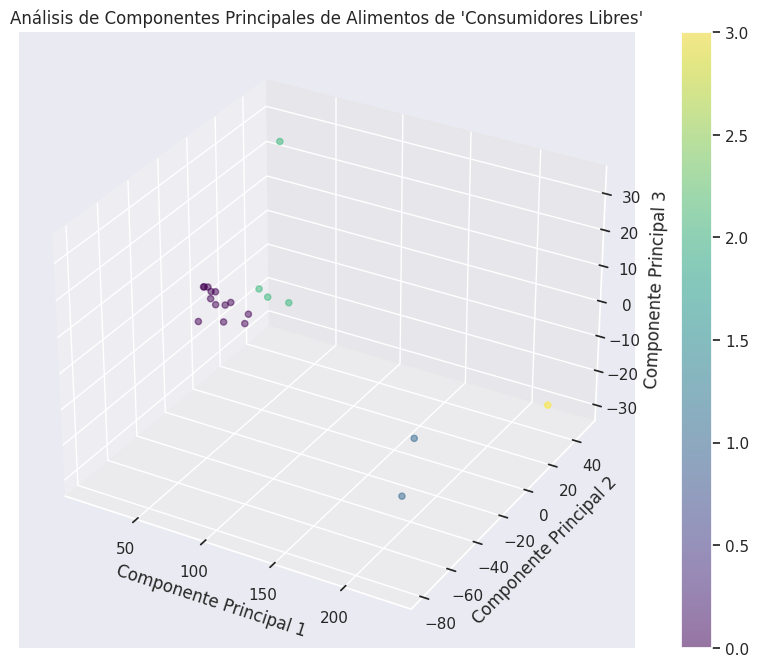

In [19]:

Y = nutricional_filtrada
alimentos2 = Y['Alimento'].values
Y = Y.iloc[:,1:].values
proyector =  Vt_3
Y_proyectado = proyectar(Y, proyector)
# Graficamos la proyección con los clusters y obtenemos el DataFrame de clusters
df_clusters_consumidores = graficarProyeccion3D(Y_proyectado, alimentos2, "Análisis de Componentes Principales de Alimentos de 'Consumidores Libres'") #guardamos el df para más adelante


In [20]:
df_clusters_consumidores

,Alimento,Número de Cluster
0,leche fluida entera,1
1,huevo,0
2,asado,0
3,paleta,0
4,carne picada,0
5,bola de lomo,0
6,acelga,0
7,zanahoria,0
8,tomate,0
9,cebolla,0


Vemos representados los 19 alimentos de la tabla consumidores libres, de acuerdo a sus valores nutricionales en la tabla nutricional.Realizamos la agrupación por clusters que utilizaremos más adelante para la sustitución de alimentos.

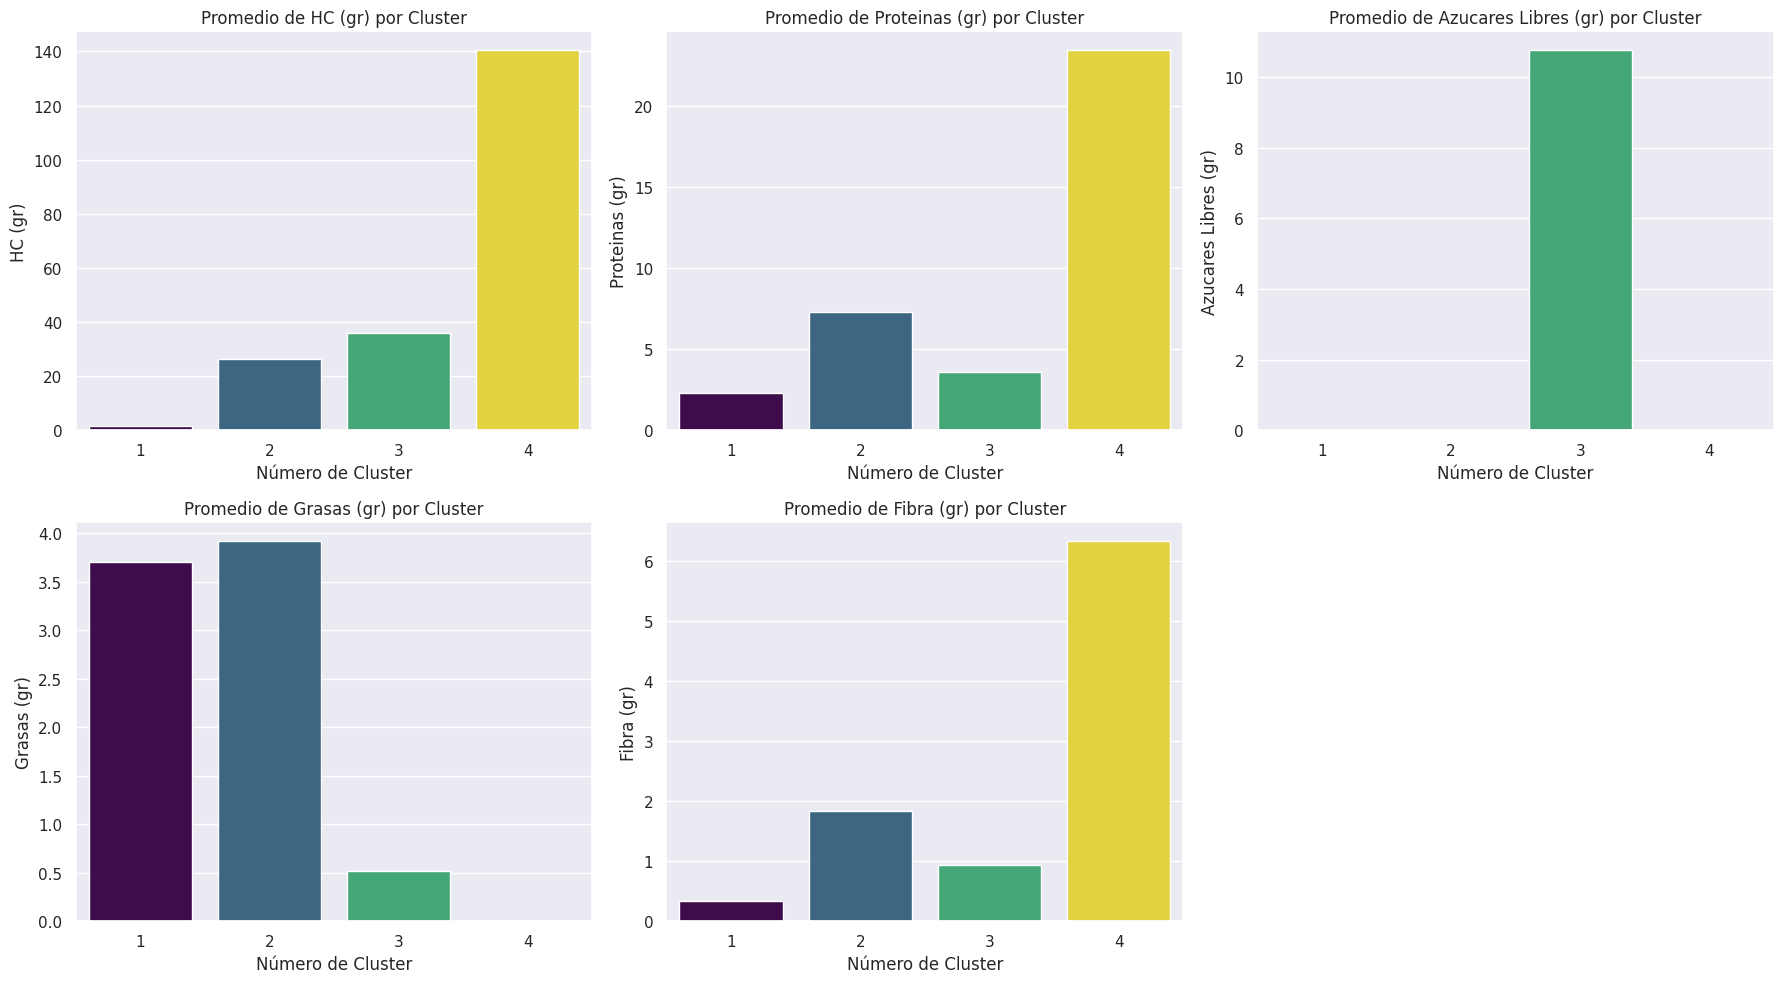

cantidad de alimentos cluster 1: 13
cantidad de alimentos cluster 2: 2
cantidad de alimentos cluster 3: 4
cantidad de alimentos cluster 4: 1


In [21]:
c1,c2,c3,c4 = graficos_cluster(df_clusters_consumidores)

Recordando que los alimentos proyectados en el grafico *Análisis de componentes principales de los alimentos de 'Consumidores Libres'* es un subgrupo de los proyectados en el grafico *Analisis de Componentes principales de los alimentos de la Tabla nutricional*, es decir son menos alimentos, veamos como se realizó la agrupación de clusters.

El cluster con más alimentos es el cluster 1

In [22]:
print('Cluster número 1')
c1

Cluster número 1


,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,huevo,16.0,0.00,1.92,1.89,0.02160,0.00896,0.00040,0.0,0.51,0.72,0.460,0.00,0
1,asado,50.0,0.00,9.30,7.50,0.03300,0.00750,0.00112,0.0,2.93,3.27,0.189,0.00,0
2,paleta,15.0,0.00,3.00,1.50,0.00990,0.00180,0.00034,0.0,0.88,0.98,0.056,0.00,0
3,carne picada,27.0,0.00,5.40,2.70,0.01782,0.00324,0.00060,0.0,1.58,1.77,0.100,0.00,0
4,bola de lomo,34.0,0.00,7.21,0.48,0.02142,0.00102,0.00118,0.0,1.99,2.20,0.130,0.00,0
5,acelga,25.0,0.00,0.73,0.00,0.05875,0.02875,0.00045,0.0,0.00,0.00,0.000,0.40,0
6,zanahoria,27.0,2.16,0.29,0.00,0.00594,0.00999,0.00013,0.0,0.00,0.00,0.000,0.82,0
7,tomate,69.0,2.83,0.69,0.00,0.00345,0.00621,0.00115,0.0,0.00,0.00,0.000,0.83,0
8,cebolla,44.0,0.97,0.35,0.00,0.01144,0.01144,0.00025,0.0,0.00,0.00,0.000,0.57,0
9,manzana,61.0,9.09,0.18,0.00,0.00305,0.00244,0.00031,0.0,0.00,0.00,0.000,0.85,0


Vemos que a comparacion de los demas clusters, tiene un alto contenido de grasas, sin embargo, es importante destacar que los alimentos en los demas clusters, son menores a 5, razon por la cual en cuatro de los cinco graficos, el cluster número 4 (que tiene 1 alimento) es el de mayor promedio.

In [23]:
print('Cluster número 4')
c4

Cluster número 4


,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,pan frances,234.0,140.4,23.4,0.0,0.31824,0.04446,0.00779,0.0,0.0,0.0,0.0,6.32,3


In [24]:
print('Cluster número 3')
c3

Cluster número 3


,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,arroz,36.0,28.51,2.48,0.00,0.00144,0.00324,0.00025,0.0,0.000,0.000,0.000,0.97,2
1,harina trigo,45.0,30.92,4.63,1.21,0.00450,0.00495,0.00068,0.0,0.190,0.110,0.510,1.44,2
2,fideos secos,56.0,40.65,7.15,0.88,0.00392,0.01008,0.00240,0.0,0.126,0.104,0.362,1.34,2
3,azucar,43.0,43.00,0.00,0.00,0.00000,0.00000,0.00000,43.0,0.000,0.000,0.000,0.00,2


In [25]:
print('Cluster número 2')
c2

Cluster número 2


,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr),Número de Cluster
0,leche fluida entera,270.0,12.42,8.37,7.83,0.15390,0.28350,0.000189,0.0,4.99,2.19,0.52,0.00,1
1,papa,229.0,40.53,6.18,0.00,0.05496,0.05725,0.001970,0.0,0.00,0.00,0.00,3.66,1


##***Mínimos cuadrados***

En esta sección, aplicaremos el método de *MínimosCuadrados* para analizar y modelar la relación entre los precios de los alimentos y su contenido nutricional en la canasta básica.

**¿Qué es el Método de Mínimos Cuadrados?**

Es una técnica matemática que se utiliza para ajustar un modelo a los datos observados de manera tal que la suma de los cuadrados de las diferencias (residuos) entre los valores observados y los valores predichos por el modelo sea mínima.

In [26]:
# Eliminamos la fila correspondiente a "berenjenas", ya que no tenemos coincidencia en la tabla nutricional
consumidores_libres = consumidores_libres[consumidores_libres['PRODUCTOS'] != 'berenjenas']


Ahora procedemos a obtener los precios de los macronutrientes de acuerdo a la composición de cada produto y su precio según el mes.

Para lograr esto, seguimos el siguiente razonamiento:

* Valores de  $X$ : meses = ['31/12/2023', '31/1/2024', '29/2/2024', '31/3/2024', '30/4/2024']
* Valores de $Y$: Son los precios por gramos de nutriente.

Realizamos tres scatterplots para visualizar la relación entre los precios y los macronutrientes: uno para carbohidratos (HC), uno para proteínas y otro para grasas totales.

-----------------

**Procedimiento**

1. **Acceder a un alimento**: Iteramos a través de la tabla nutricional.
2. **Obtener contenido nutricional**:
Obtenemos cuánta proteína hay en el alimento según su cantidad en gramos.

3. **Buscar en consumidores libres:**
Buscamos el alimento en la base de datos de precios (el nombre puede no ser exacto, usamos str.contains para verificar).
Obtenemos la cantidad para la cual tenemos precio (cant_con_precio).
4. **Realizar la conversión:**
Por ejemplo, si 250 gr de fideos contienen 5 gr de proteínas

$$
\begin{array}{ccc}
250 \text{ gr de fideos} & \rightarrow & 5 \text{ gr de proteínas} \\
1000 \text{ gr de fideos} & \rightarrow & X \text{ gr de proteínas} \\
\end{array}
$$

$$
X = \frac{1000 \times 5}{250} = 20 \text{ gr de proteínas}
$$

5. **Obtener el precio del nutriente:**
Si 1000 gr de fideos cuestan $300, calculamos el precio de los gramos de proteína

$$
\begin{array}{ccc}
1000 \text{ gr de fideos} & \rightarrow & \$300 \\
20 \text{ gr de proteínas} & \rightarrow & X \\
\end{array}
$$

$$
X = \frac{20 \times 300}{1000} = \$6
$$

6. **Graficar:** Finalmente realizamos un gráfico para cada nutriente

---------------

A continuación se muestra el código para el procedimiento descripto.



In [27]:
#listamos las fechas
meses = ['31/12/2023', '31/1/2024', '29/2/2024', '31/3/2024', '30/4/2024']

# Inicializamos diccionarios para almacenar los precios por gramos de cada nutriente
precios_hc = {}
precios_proteinas = {}
precios_grasas = {}
precios_carne ={}

#listamos casos excepcionales que quedan fuera al filtrar
casos_excepcionales ={
        'aceite girasol': 'aceite cocinero girasol',
    'fideos secos': 'fideos guiseros',
    'harina trigo': 'harina de trigo',
    'leche fluida entera': 'leche c/vit.fort',
    'pan frances': 'pan fresco',
       }

# Iteramos sobre cada alimento en la tabla nutricional
for _, row in nutricional_filtrada.iterrows():

    alimento = row['Alimento'] #Toma el alimento de tabla nutricional

    cant_ali = row['Cantidad (gr/ml)'] #Toma la cantidad de ese alimento para ver su composicion en nutrientes

    gr_hc = row['HC (gr)'] #toma su composición en gramos de carbohidratos

    gr_proteinas = row['Proteinas (gr)'] #toma su composición en gramos de proteinas

    gr_grasas = row['Grasas (gr)'] #toma su composición en gramos de grasas

    # Buscamos alimento en consumidores libres
    if alimento in casos_excepcionales.keys():
       alimento =  casos_excepcionales[alimento]

    match = consumidores_libres[consumidores_libres['PRODUCTOS'].str.contains(alimento)] # utilizamos una sentencia match para comparar patrones y extraer componentes

    if not match.empty: # evitamos operar con el producto 'yerba', ya que contiene 0 proteinas,grasas y hc

        cant_con_precio = match.iloc[0]['Cantidad'] #guardamos la cantidad  para la cual tenemos precio

        precios = match.iloc[0][meses].values #listamos los precios

        # Calculamos precios por gramo de nutriente
        if gr_hc > 0:
            #aplico regla de tres

            x = (gr_hc*cant_con_precio)/cant_ali

            #ahora veo para los gramos dados
            y = (precios*x)/cant_con_precio

            #ahora saco para un gramo
            precio_hc = y/x

            precios_hc[alimento] = precio_hc #guardamos el precio obtenido
        if gr_proteinas > 0:
            #aplico regla de tres

            x = (gr_proteinas*cant_con_precio)/cant_ali
            #ahora veo para los gramos dados

            y = (precios*x)/cant_con_precio
            #ahora saco para un gramo

            precio_proteinas = y/x

            precios_proteinas[alimento] = precio_proteinas
        if gr_grasas > 0:
            #aplico regla de tres

            x = (gr_grasas*cant_con_precio)/cant_ali
            #ahora veo para los gramos dados

            y = (precios*x)/cant_con_precio

            #ahora saco para un gramo

            precio_grasas = y/x

            precios_grasas[alimento] = precio_grasas

#convertimos en dataframes los diccioanrios obtenidos y trasponemos para una mejor organización y visuaizacion.
#las columnas seran los meses y los indices de las filas, los alimentos
df_hc = pd.DataFrame(precios_hc, index=meses).T
df_proteinas = pd.DataFrame(precios_proteinas, index=meses).T
df_grasas = pd.DataFrame(precios_grasas, index=meses).T

print('Vemos el formato de las tablas obtenidas:')
df_hc.head(3)


Vemos el formato de las tablas obtenidas:


,31/12/2023,31/1/2024,29/2/2024,31/3/2024,30/4/2024
leche c/vit.fort,1.1,1.21,1.62,1.89,1.99
zanahoria,0.82,0.99,1.1,1.1,1.1
tomate,1.2,1.1,1.2,2.3,2.7


Creamos una funcón para realizar el gráfico, aplicando la interpolación por mínimos cuadrados y graficamos ambas, para cada nutriente.

In [28]:
def minimosCuadrados_grafico(df, titulo):
    """
    Genera un gráfico de precios originales y su interpolación por mínimos cuadrados
    para diferentes alimentos a lo largo de cinco meses.

    Parámetros:
    df -- DataFrame donde las filas son alimentos y las columnas son los precios mensuales.
    titulo -- Título del gráfico.
    """
    plt.figure(figsize=(12, 8))
    mes_indices = np.array([0, 1, 2, 3, 4])  #tomamos 5 fechas de datos
    colors = list(mcolors.TABLEAU_COLORS.values())

    for i, alimento in enumerate(df.index):
        precios = df.loc[alimento].values.astype(np.float64)  # Convertimos a float64 por problemas al compilar

        # Realizamos las ecuaciones normales
        A = np.vstack([mes_indices, np.ones(len(mes_indices))]).T
        ATA = A.T @ A
        ATy = A.T @ precios

        # Resolvemos el sistema de ecuaciones
        coef = np.linalg.solve(ATA, ATy)
        m, b = coef


        color = colors[i % len(colors)]

        # Graficamos precios originales
        plt.plot(mes_indices, precios, 'o', label=f'{alimento} (original)', color=color)

        # Graficamos la interpolacion por minimos cuadrados
        plt.plot(mes_indices, m * mes_indices + b, '-', label=f'{alimento} (Interpolacion)', color=color)

        plt.xlabel('Meses')
        plt.ylabel('Precio por gramo de nutriente')
        plt.title(titulo)
    plt.grid(True)

    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xticks(mes_indices, ['Dic23', 'Ene24', 'Feb24', 'Mar24', 'Abr24'])
    plt.show()


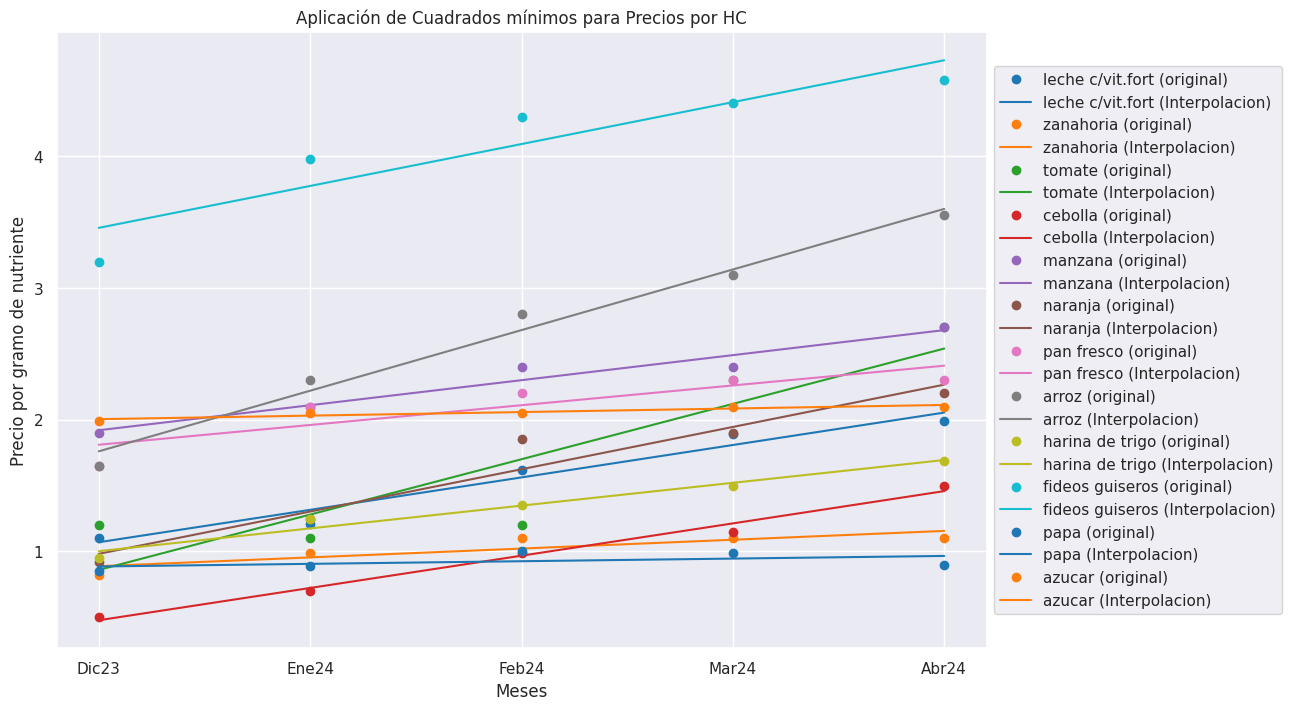

In [29]:

minimosCuadrados_grafico(df_hc, 'Aplicación de Cuadrados mínimos para Precios por HC')


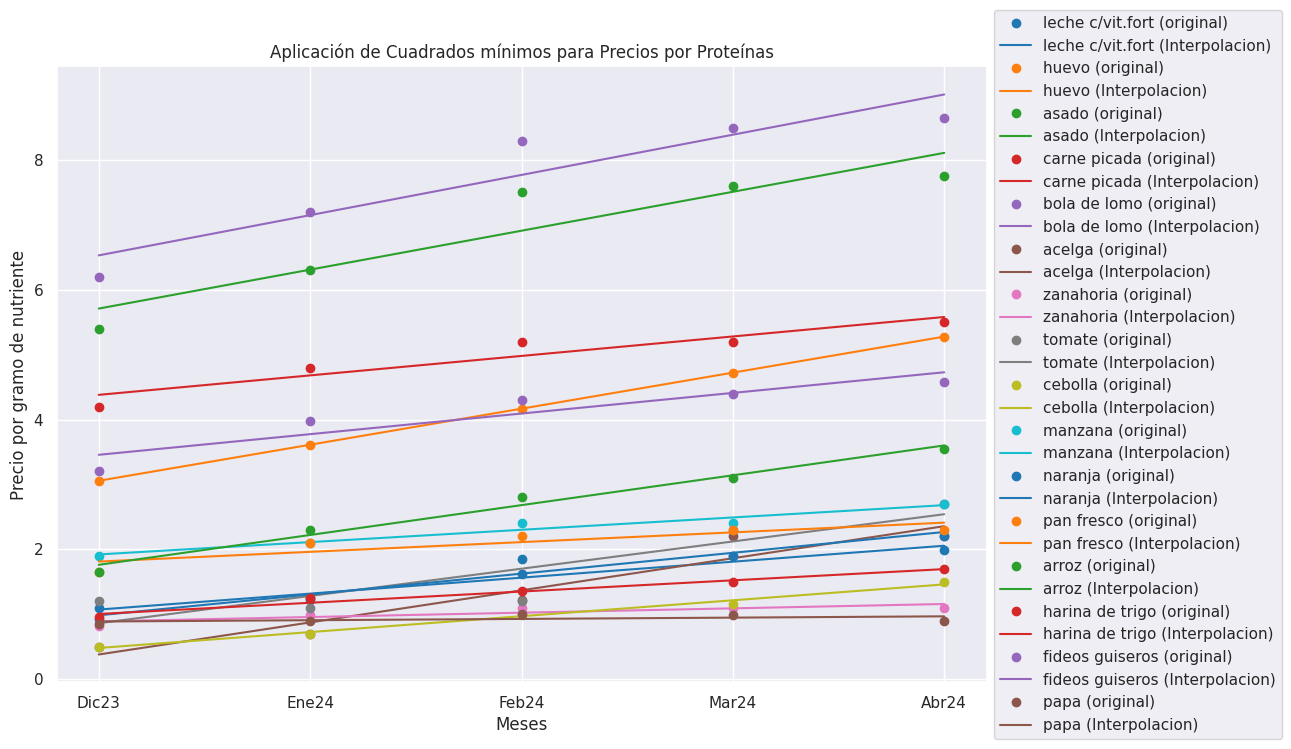

In [30]:
minimosCuadrados_grafico(df_proteinas, 'Aplicación de Cuadrados mínimos para Precios por Proteínas')



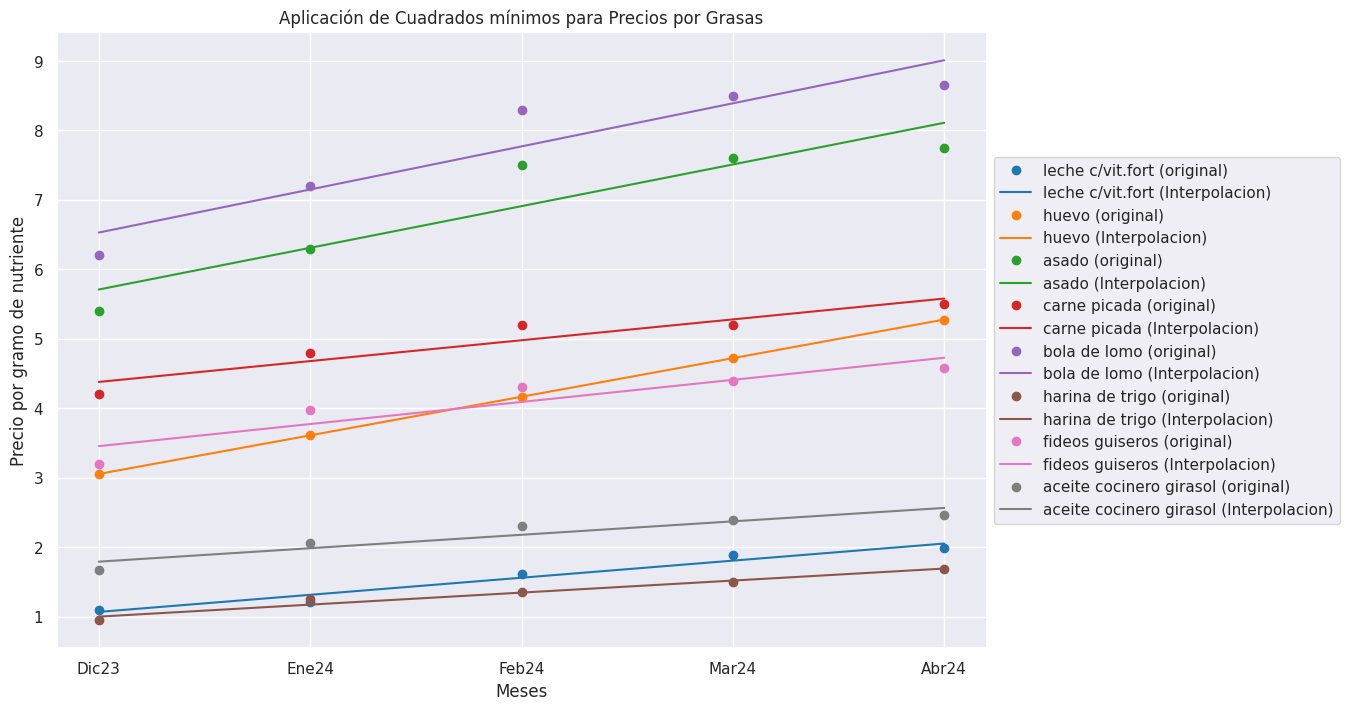

In [31]:
minimosCuadrados_grafico(df_grasas, 'Aplicación de Cuadrados mínimos para Precios por Grasas')


Ahora buscamos graficar como se comportan los precios de los nutrientes de acuerdo al promedio de los precios obtenidos por alimento por nutriente.
$$\text{Promedio precio nutriente} = \frac{\sum_{i=1}^{n} x_i}{n}
$$

Donde $n$ representa a la cantidad de productos y $x_i$ el precio de cada nutriente por alimento.

Para ello, realizamos una funciòn que aplique el método de mínimos cuadrados, realizando las ecuaciones normales y resolviendo el sistema de ecuaciones, buscando una aproximacion lineal $mx + b$
Finalmente, graficamos.

In [32]:
def minimos_cuadrados(x, y):
    """
    Calcula los coeficientes de la línea de regresión lineal y = mx + b
    utilizando el método de mínimos cuadrados.

    Parámetros:
    x -- vector de valores independientes
    y -- vector de valores dependientes

    Retorna:
    m -- pendiente de la línea de regresión
    b -- intersección con el eje y
    """
    A = np.vstack([x, np.ones(len(x))]).T
    ATA = A.T @ A
    ATy = A.T @ y

    # Resolver el sistema de ecuaciones
    coef = np.linalg.solve(ATA, ATy)
    m, b = coef

    return m, b

def grafico_promedio_nutrientes(grasas, hc, proteinas):
    """
    Genera un gráfico de dispersión con ajuste por mínimos cuadrados
    para los precios promedio por gramo de grasas, carbohidratos (HC)
    y proteínas a lo largo del tiempo.

    Parámetros:
    grasas -- DataFrame con los precios de grasas por productos
    hc -- DataFrame con los precios de carbohidratos por productos
    proteinas -- DataFrame con los precios de proteínas por productos
    """

    precios_promedio_grasas = []
    precios_promedio_hc = []
    precios_promedio_proteinas = []

    for fecha in meses:
        # Calcular el precio promedio por gramo de grasas
        precio_promedio_grasas = grasas[fecha].mean()
        precios_promedio_grasas.append(precio_promedio_grasas)

                # Calcular el precio promedio por gramo de HC
        precio_promedio_hc = hc[fecha].mean()
        precios_promedio_hc.append(precio_promedio_hc)

                # Calcular el precio promedio por gramo de proteínas
        precio_promedio_proteinas = proteinas[fecha].mean()
        precios_promedio_proteinas.append(precio_promedio_proteinas)

    # Crear el gráfico de dispersión y ajuste por mínimos cuadrados
    plt.figure(figsize=(12, 8))

    x = np.arange(len(meses))
    m, b = minimos_cuadrados(x, precios_promedio_grasas)
    plt.scatter(x, precios_promedio_grasas, label='Grasas', color='blue')
    plt.plot(x, m * x + b, '-', label='Grasas (Interpolación)', color='blue')

    m, b = minimos_cuadrados(x, precios_promedio_hc)
    plt.scatter(x, precios_promedio_hc, label='HC', color='green')
    plt.plot(x, m * x + b, '-', label='HC (Interpolación)', color='green')

    m, b = minimos_cuadrados(x, precios_promedio_proteinas)
    plt.scatter(x, precios_promedio_proteinas, label='Proteínas', color='red')
    plt.plot(x, m * x + b, '-', label='Proteínas (Interpolación)', color='red')

    plt.xlabel('Fecha')
    plt.ylabel('Precio Promedio por Gramo de MacroNutriente')
    plt.title('Precio Promedio por Gramo de Macronutriente en funcion del tiempo')
    plt.xticks(x, meses, rotation=45)
    plt.legend()
    plt.grid(True)


    plt.show()

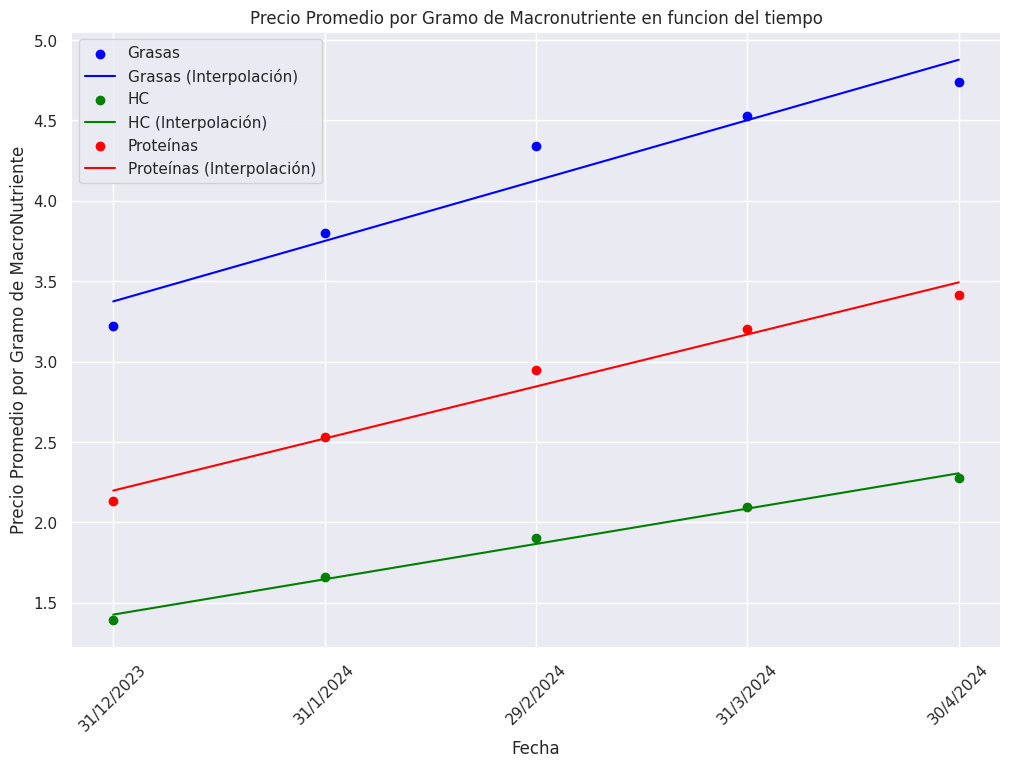

In [33]:
grafico_promedio_nutrientes(df_grasas, df_hc, df_proteinas)


Ahora armamos un datframe con los aumentos de los nutrientes por alimento. Para ello, calculamos el aumento,nuevamente utilizando el método de mínimos cuadrados, siendo el aumento la pendiente, debido a que refleja la tasa de crecimiento.

In [34]:
def calcular_aumentos(df):
    mes_indices = np.array([0, 1, 2, 3, 4])  # Asume que tenes 5 meses de datos
    aumentos = {}

    for alimento in df.index:
        precios = df.loc[alimento].values.astype(np.float64)

        A = np.vstack([mes_indices, np.ones(len(mes_indices))]).T
        ATA = A.T @ A
        ATy = A.T @ precios

        coef = np.linalg.solve(ATA, ATy)
        m, b = coef

        aumentos[alimento] = m

    return aumentos

Guardamos los aumentos en tablas y armamos un solo dataframe con todos los alimentos y los aumentos por macronutriente.

In [35]:
aumentos_hc = calcular_aumentos(df_hc)
aumentos_proteinas = calcular_aumentos(df_proteinas)
aumentos_grasas = calcular_aumentos(df_grasas)

#convertimos los diccionarios a dataframes

aumentos_hc = pd.DataFrame(list(aumentos_hc.items()), columns=['Alimento', 'Aumento HC'])
aumentos_proteinas = pd.DataFrame(list(aumentos_proteinas.items()), columns=['Alimento', 'Aumento Proteínas'])
aumentos_grasas = pd.DataFrame(list(aumentos_grasas.items()), columns=['Alimento', 'Aumento Grasas'])

#unimos los datframes
aumentos_nutrientes = pd.merge(aumentos_hc, aumentos_proteinas, on='Alimento', how='outer')
aumentos_nutrientes = pd.merge(aumentos_nutrientes, aumentos_grasas, on='Alimento', how='outer')

#completamos las columnas con cero, que no fueron consideradas aal separar por macronutriente
aumentos_nutrientes = aumentos_nutrientes.fillna(0)
aumentos_nutrientes.head()


,Alimento,Aumento HC,Aumento Proteínas,Aumento Grasas
0,leche c/vit.fort,0.246,0.246,0.246
1,zanahoria,0.067,0.067,0.000
2,tomate,0.420,0.420,0.000
3,cebolla,0.245,0.245,0.000
4,manzana,0.190,0.190,0.000


La tasa de aumento $m$ representa la pendiente de la línea de regresión que mejor se ajusta a los datos de precios del producto a lo largo del tiempo, indicando el cambio promedio en el precio por mes.

##**¿Y si consumimos menos carne?**

Ahora, procedemos a analizar el aumento de las carnes en comparación con los otros alimentos.


In [36]:
#Adaptamos la función calcular aumentos para poder usarla con consumidores libres
#calculamos aumento por alimento

def calcular_aumentos_productos(df):
    """
    Calcula la tasa de aumento de precios de diferentes alimentos
    utilizando el método de mínimos cuadrados a lo largo de cinco meses.

    Parámetros:
    df -- DataFrame donde las filas son alimentos y las columnas son
          los precios mensuales.

    Retorna:
    aumentos -- Diccionario con la tasa de aumento de precios para
                cada alimento.
    """
    mes_indices = np.array([0, 1, 2, 3, 4])  # Asume que tienes 5 meses de datos
    aumentos = {}

    for producto in df['PRODUCTOS']:
        precios = df[df['PRODUCTOS'] == producto].iloc[0, 2:].values.astype(np.float64)

        #ecuaciones normales
        A = np.vstack([mes_indices, np.ones(len(mes_indices))]).T
        ATA = A.T @ A
        ATy = A.T @ precios

        coef = np.linalg.solve(ATA, ATy)
        m, b = coef

        aumentos[producto] = m

    return aumentos


In [37]:

# Calcular los aumentos (obtenemos la pendiente como tasa de crecimiento para la interpolacion)
aumentos_productos = calcular_aumentos_productos(consumidores_libres)
#convertimos el diccionario a un dataframe
aumentos_productos = pd.DataFrame(list(aumentos_productos.items()), columns=['Productos', 'Aumento'])
aumentos_productos.head()


,Productos,Aumento
0,aceite cocinero girasol,290.0
1,arroz grano fino,460.0
2,azucar ledesma,27.0
3,fideos guiseros,159.0
4,harina de trigo,173.0


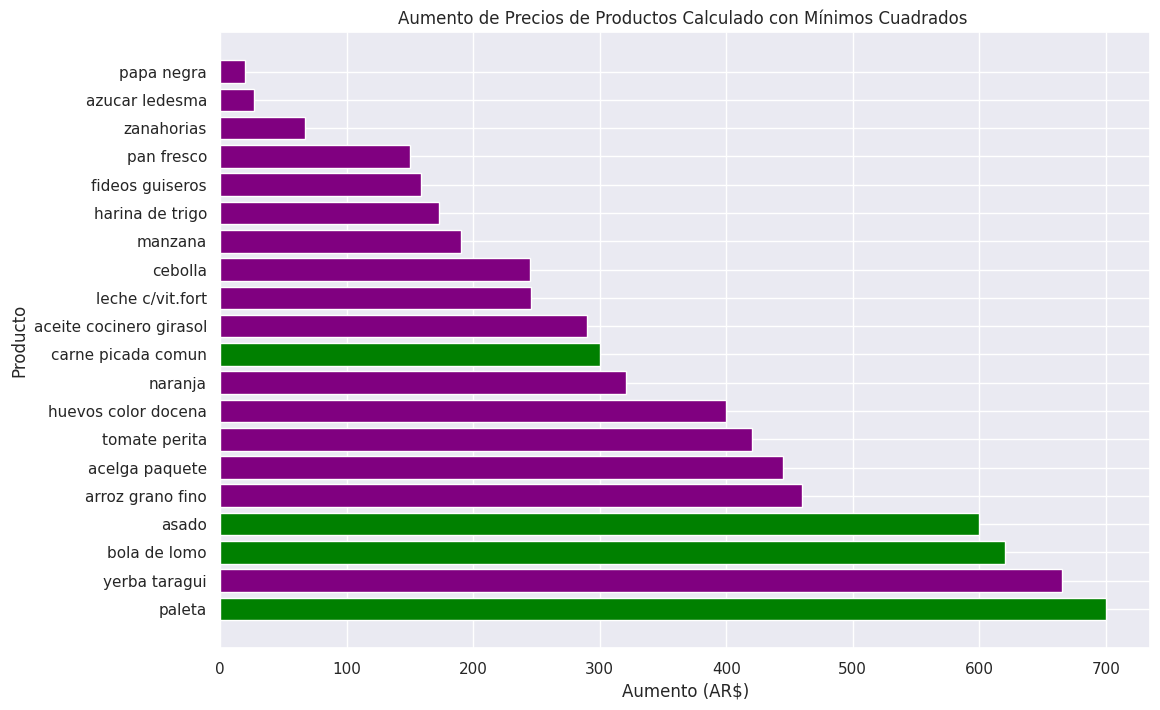

In [38]:
# ordenamos para una mejor visualizacion
aumentos_productos = aumentos_productos.sort_values(by='Aumento', ascending=False)
#listamos las carnes y las distinguimos con otro color
carnes = ['asado','bola de lomo','carne picada comun','paleta']


plt.figure(figsize=(12, 8))
colores = ['purple' if producto not in carnes else 'green' for producto in aumentos_productos['Productos']]

plt.barh(aumentos_productos['Productos'], aumentos_productos['Aumento'], color=colores)
plt.xlabel('Aumento (AR$)')
plt.ylabel('Producto')
plt.title('Aumento de Precios de Productos Calculado con Mínimos Cuadrados ')
plt.grid(True)
plt.show()

Ahora calculamos el aumento porcentual utilizando la formula :         
$$\text{Aumento porcentual} = \left( \frac{\text{Precio final} - \text{Precio inicial}}{\text{Precio inicial}} \right) \times 100$$

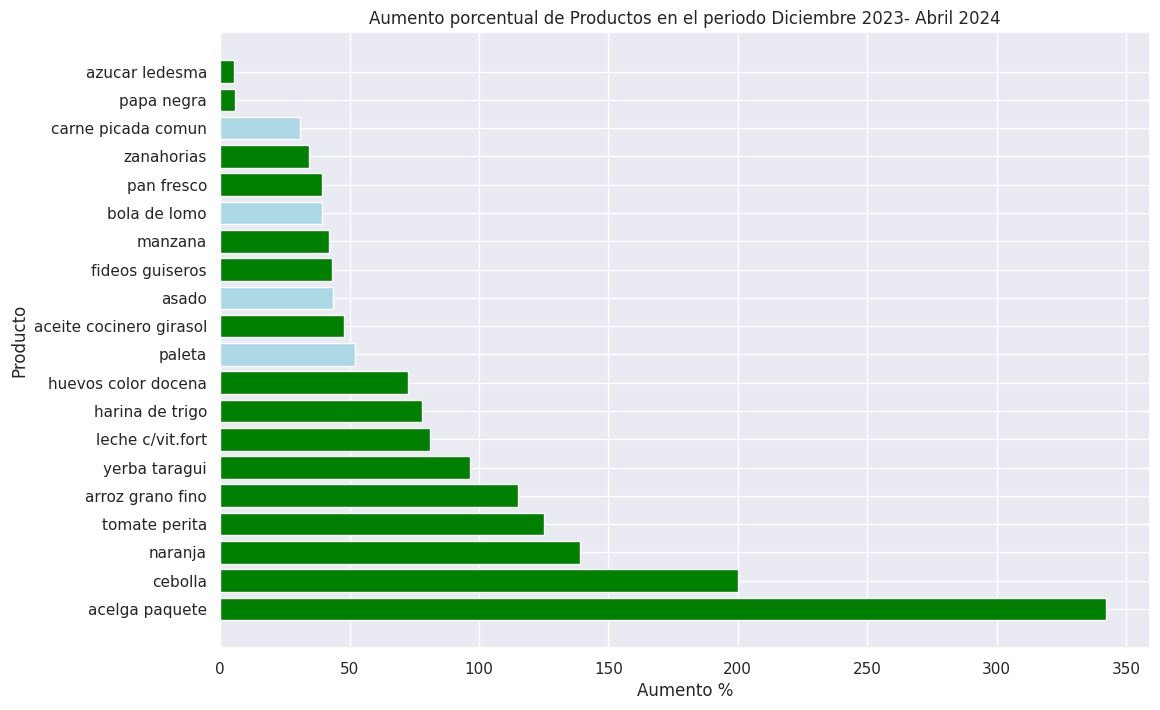

In [39]:
def calcular_aumento_porcentual(df, fecha_inicio, fecha_fin):
    """
    Calcula el aumento porcentual de precios de productos dadas dos fechas

    Parámetros:
    df -- DataFrame que contiene los precios de los productos en diferentes fechas.
    fecha_inicio -- La fecha de inicio como una cadena en el formato 'dd/mm/yyyy'.
    fecha_fin -- La fecha de fin como una cadena en el formato 'dd/mm/yyyy'.

    Retorna:
    df_resultado -- DataFrame con los productos y su correspondiente aumento porcentual de precio
                    entre las dos fechas dadas
    """
    # Calcula el aumento porcentual para cada fila entre las columnas especificadas
    df['Aumento %'] = ((df[fecha_fin] - df[fecha_inicio]) / df[fecha_inicio]) * 100

    # Crea un nuevo DataFrame solo con las columnas 'PRODUCTOS' y 'Aumento %'
    df_resultado = df[['PRODUCTOS', 'Aumento %']].copy()

    return df_resultado

#creamos un dataframe con el nombre de los alimentos y su aumento porcentual
aumento_porcentual_productos = calcular_aumento_porcentual(consumidores_libres.copy(), '31/12/2023', '30/4/2024')

#ordenamos de manera descencente
aumento_porcentual_productos = aumento_porcentual_productos.sort_values(by='Aumento %', ascending=False)
carnes = ['asado', 'bola de lomo', 'carne picada comun', 'paleta']

plt.figure(figsize=(12, 8))
colores = ['green' if producto not in carnes else 'lightblue'
           for producto in aumento_porcentual_productos['PRODUCTOS']]
plt.barh(aumento_porcentual_productos['PRODUCTOS'], aumento_porcentual_productos['Aumento %'], color=colores)
plt.xlabel('Aumento %')
plt.ylabel('Producto')
plt.title('Aumento porcentual de Productos en el periodo Diciembre 2023- Abril 2024')
plt.grid(True)
plt.show()


Podemos observar en ambos graficos como la carne (en celeste) es de los alimentos más caros consumidos, pero sin embargo tuvieron poco aumento porcentual en relación a otros alimentos.

En diciembre de 2023, un paquete de acelga costaba 450 pesos para en abril de 2024 costar 1990 pesos, mientras que la paleta costaba en un inicio 5200 pesos y en abril de 2024, alcanzó el precio de 7900 pesos. Por lo que tuvo un aumento porcentual del 50% aproximadamente, mientras que el paquete de acelga sufrió un aumento de casi el 350%.
En otras palabras, las carnes (cuya representación en la tabla son la paleta, asado, bola de lomo y carne picada) son de los alimentos más caros consumidos por los argentinos, sin embargo solo sufrieron un aumento del 40-50% comparados con otros alimentos que tuvieron un aumento de más del 70%.

------
Veamos como son los valores de los macronutrientes en estos alimentos.


In [40]:
carnes = ['asado', 'bola de lomo', 'carne picada','paleta ']

#seleccionamos las carnes para ver sus valores
carnes_df = nutricional_filtrada[nutricional_filtrada['Alimento'].isin(carnes)]

columnas = nutricional_filtrada.columns
carnes_nutrientes = carnes_df[columnas]

#tomamos las columnass que queremos ver
columnas_interes = ['Alimento', 'Cantidad (gr/ml)','HC (gr)', 'Proteinas (gr)',
       'Grasas (gr)']

carnes_nutrientes_seleccionado = carnes_nutrientes[columnas_interes]
carnes_nutrientes_seleccionado


,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr)
7,asado,50.0,0.0,9.30,7.50
8,paleta,15.0,0.0,3.00,1.50
10,carne picada,27.0,0.0,5.40,2.70
11,bola de lomo,34.0,0.0,7.21,0.48


Ahora calculamos cuanto aumentó la carne en promedio.

In [41]:

 #extraigo el porcentaje
carnes_porcentaje = aumento_porcentual_productos[aumento_porcentual_productos['PRODUCTOS'].isin(carnes)]
resultado = carnes_porcentaje['Aumento %'].mean()

print(f'El porcentaje de aumento de la carne es: {resultado.round(2)}%')

El porcentaje de aumento de la carne es: 41.52%


Vemos que las carnes tienen una alta composición de grasas y proteinas. Observemoslo en filtrando el dataframe de la tabla nutricional original.

In [42]:
# Ordenar el DataFrame por la columna 'Proteinas' en orden descendente
df_ordenado = nutricional_filtrada.sort_values(by='Proteinas (gr)', ascending=False)

# Seleccionar las columnas 'HC (gr)', 'Proteinas (gr)' y 'Grasas (gr)'
df_seleccionado = df_ordenado[['Alimento','HC (gr)', 'Proteinas (gr)', 'Grasas (gr)']]

# Mostrar los primeros cinco elementos
df_seleccionado.head()


,Alimento,HC (gr),Proteinas (gr),Grasas (gr)
26,pan frances,140.40,23.40,0.00
7,asado,0.00,9.30,7.50
0,leche fluida entera,12.42,8.37,7.83
11,bola de lomo,0.00,7.21,0.48
30,fideos secos,40.65,7.15,0.88


Vemos que el asado y la bola de lomo se encuentran entre los cinco primeros alimentos con mayor gramos de proteinas en la tabla nutricional. Veamos respecto a las grasas

In [43]:

df_ordenado = nutricional_filtrada.sort_values(by='Grasas (gr)', ascending=False)

df_seleccionado = df_ordenado[['Alimento','HC (gr)', 'Proteinas (gr)', 'Grasas (gr)']]

df_seleccionado.head()


,Alimento,HC (gr),Proteinas (gr),Grasas (gr)
33,aceite girasol,0.00,0.00,34.00
0,leche fluida entera,12.42,8.37,7.83
7,asado,0.00,9.30,7.50
10,carne picada,0.00,5.40,2.70
6,huevo,0.00,1.92,1.89


Nuevamente, el asado y ahora la carne picada, se encuentran entre los cinco primeros alimentos con mayor cantidad de gramos de grasas en la tabla nutricional.

Por lo tanto, vemos que el consumo de las carnes tiene un alto impacto en el contenido nutricional. Tambien sabemos que es uno de los alimentos con precio alto,cuyo aumento entre diciembre del 2023 y abril de 2024 fue de casi el 50%.

Veamos que sucede, si en la tabla nutricional reducimos ese aumento en estos alimentos.

--------------
En otras palabras, si el asado aumentó un 45%, veamos que sucede con los márgenes de la OMS para la canasta básica argentina, si la población consume ese porcentaje menos de asado

In [44]:
# Listamos las carnes
carnes = ['asado', 'bola de lomo', 'carne picada comun', 'paleta']

# manejamos excepciones
similares = {'carne picada comun': 'carne picada '}

#guardamos el porcentaje de aumento para las carnes
carnes_porcentaje = aumento_porcentual_productos[aumento_porcentual_productos['PRODUCTOS'].isin(carnes)]

# creamos una copia para reducir el aumento, sin modificar la tabla original
cba_reducida = tabla_nutricional.copy()

# Iteramos sobre cada fila del dataframe de aumento porcentual
for index, row in carnes_porcentaje.iterrows():
    alimento = row['PRODUCTOS']
    aumento_porcentaje = row['Aumento %']

    if alimento in similares:
        alimento = similares[alimento]

    # Buscar el alimento en cba_reducida y aplicar la reducción
    mask = cba_reducida['Alimento'].str.strip() == alimento.strip()

    if mask.any():
        # Calcular el factor de reducción
        factor_reduccion = (100 - aumento_porcentaje) / 100.0

        # Reducir los valores en las columnas relevantes
        cba_reducida.loc[mask, 'Cantidad (gr/ml)'] *= factor_reduccion
        cba_reducida.loc[mask, 'HC (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Proteinas (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Grasas (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Na (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Ca (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Fe (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Azucares Libres (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'AGS (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'AGNI (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'AG p (gr)'] *= factor_reduccion
        cba_reducida.loc[mask, 'Fibra (gr)'] *= factor_reduccion


verificamos si al realizar esta reducción cumple con los márgenes de la OMS, recordemos que las carnes contribuyen una cantidad importante de proteinas y grasas.

In [45]:
print('Vemos como quedan los margenes al reducir el consumo')
print('*'*50)
print(evaluarCumplimiento_dieta_margenes(cba_reducida)[0])
df_carne_reducida = evaluarCumplimiento_dieta_margenes(cba_reducida)[1]


Vemos como quedan los margenes al reducir el consumo
**************************************************
No cumple los márgenes


In [46]:
df_carne_reducida

,Nutriente,Cumple,Valor,Unidad
0,proteinas,True,14.88,Calorias
1,carbohidratos,True,59.67,Calorias
2,grasas,True,23.51,Calorias
3,sodio,False,3.30,gr
4,fibra,False,21.26,gr/dia
5,frutas y verduras,False,16.00,gr


In [47]:

print('*'*50)
print('Comparamos con los margenes de la tabla original')
print(evaluarCumplimiento_dieta_margenes(tabla_nutricional)[0])
df = evaluarCumplimiento_dieta_margenes(tabla_nutricional)[1]
#Ahora mostramos el datframe con la informacion de los nutrientes y sus valores

print('*'*50)

**************************************************
Comparamos con los margenes de la tabla original
No cumple los márgenes
**************************************************


In [48]:
df

,Nutriente,Cumple,Valor,Unidad
0,proteinas,False,16.35,Calorias
1,carbohidratos,True,59.67,Calorias
2,grasas,True,25.17,Calorias
3,sodio,False,3.34,gr
4,fibra,False,21.26,gr/dia
5,frutas y verduras,False,16.00,gr


Vemos que nuevamente, si se reduce el consumo de carne de acuerdo a su aumento, la Canasta básica, sigue sin cumplir los márgenes de la OMS. No obstante, el porcentaje de proteinas consumidas ahora es el correcto.

Las carnes, tienen un alto contenido de proteinas (comparadas con la mayoría de los alimentos de la CBA) por lo que su reducción es un impacto directo en el consumo de este marconutriente.

-----------------------------

###**Reemplazo Dietario**

En esta sección reducimos el consumo de carne de la canasta básica un 18,5% y buscamos alimentos de la tabla Consumidores Libres, que puedan reemplazarlos.



In [49]:
carnes = ['asado', 'bola de lomo', 'carne picada', 'paleta ']
reduccion = 0.185
#Copiamos el dataframe para no modificar el original, trabajamos con aquellos alimentos para los cuales tenemos precio
reducida = nutricional_filtrada.copy()

# Aplicar la reducción del 18.5% a las filas correspondientes
reducida.loc[reducida['Alimento'].isin(carnes), ['Cantidad (gr/ml)', 'HC (gr)', 'Proteinas (gr)', 'Grasas (gr)', 'Na (gr)',
                                                  'Ca (gr)', 'Fe (gr)', 'Azucares Libres (gr)', 'AGS (gr)', 'AGNI (gr)']] *= (1 - reduccion)

# Calculamos la diferencia entre las filas originales y las reducidas para ver los nutrientes a compensar
fila_original = nutricional_filtrada[nutricional_filtrada['Alimento'].isin(carnes)].iloc[:, 1:]
fila_reducida = reducida[reducida['Alimento'].isin(carnes)].iloc[:, 1:]
nutrientes_a_compensar = fila_original - fila_reducida

nutrientes_a_compensar = nutrientes_a_compensar.sum()
nutrientes_a_compensar = nutrientes_a_compensar.to_frame().T
print('Nutrientes perdidos al reducir las carnes')
nutrientes_a_compensar

Nutrientes perdidos al reducir las carnes


,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr)
0,23.31,0.0,4.60835,2.2533,0.015196,0.002509,0.000599,0.0,1.3653,1.5207,0.0,0.0


Recordemos que las carnes no aportan carbohidratos y la mayoría de alimentos con los que podamos compensar, lo harán.

--------

Para hacer la selección de los alimentos sustitutos, utilizamos el espacio generado por el *ACP*., para buscar los alimentos cuyo comportamiento sea similar al de las carnes, aquellos que se encuentren agrupados en el mismo cluster.

Seguimos el siguiente procedimiento:
 * **Obtenemos el cluster**: buscamos y guardamos el número de cluster en el cual se encuentran las carnes, filtramos los alimentos de ese cluster.
 * **Obtener segundo filtro** : Los  precios de los alimentos sustitutos deben cumplir ser menor a la mitad del aumento de la carne.Calculamos este filtro, promediando.Obtenemos el aumento porcentual y en pesos.
 * **Filtramos y seleccionamos 2 alimentos**: Luego de aplicar el filtro del precio, obtenemos la lista de los posibles sustitutos y seleccionamos dos.

 Para realizar el procedimiento, escribimos el siguiente codigo:

In [50]:
#obtenemos el numero de cluster correspondiente a las carnes
nro_cluster = df_clusters_consumidores.loc[df_clusters_consumidores['Alimento'] == 'asado','Número de Cluster'].values[0]

# Filtrar los alimentos que pertenecen al mismo clúster
alimentos_mismo_cluster = df_clusters_consumidores[df_clusters_consumidores['Número de Cluster'] == nro_cluster]

alimentos_mismo_cluster

,Alimento,Número de Cluster
1,huevo,0
2,asado,0
3,paleta,0
4,carne picada,0
5,bola de lomo,0
6,acelga,0
7,zanahoria,0
8,tomate,0
9,cebolla,0
10,manzana,0


Ahora calculamos el aumento en pesos, como la diferencia entre el ultimo y el primer precio.

In [51]:
#guardamos el aumento porcentual de la carne, calculado anteriormente.
carne_aumento = resultado.round(2)

#creamos una columna que refleje el aumento en pesos de los productos
consumidores_libres['Aumento $'] = consumidores_libres['30/4/2024'] - consumidores_libres['31/12/2023']

print('Aumento de la carne:',carne_aumento)

Aumento de la carne: 41.52


Ahora agregamos esta columna al dataframe que guarda la información del aumento porcentual de los productos.

In [52]:

# Fusionamos los DataFrames aumento_porcentual_productos y consumidores_libres
aumento_porcentual_productos = pd.merge(aumento_porcentual_productos, consumidores_libres[['PRODUCTOS', 'Aumento $']], on='PRODUCTOS')

aumento_porcentual_productos.head(3)


,PRODUCTOS,Aumento %,Aumento $
0,acelga paquete,342.222222,1540.0
1,cebolla,200.000000,1000.0
2,naranja,139.130435,1280.0


Procedemos a establecer el limite de precio para los productos a seleccionar, siendo este la mitad del aumento de la carne.

In [53]:
carnes_precio = aumento_porcentual_productos[aumento_porcentual_productos['PRODUCTOS'].isin(carnes)]
limite_precio = carnes_precio['Aumento $'].mean()

print('Precio limite : ',limite_precio)

#en promedio la carne aumentó 2400 pesos,
#asi que sacamos cuales alimentos estan por debajo de la mitad de ese aumento
#filtramos por limite_precio/2
alimentos_mismo_cluster.loc[:, 'Alimento'] = alimentos_mismo_cluster['Alimento'].replace({
    'huevo': 'huevos color docena',
    'zanahoria': 'zanahorias'
})

Precio limite :  2400.0


Ahora aplicamos el filtro por la mitad de precio

In [54]:
alimentos_mismo_cluster=filtrarAlimentos(alimentos_mismo_cluster, aumento_porcentual_productos)

#ahora nos quedamos con aquellos alimentos bajo el limite
posibles_sustitutos = alimentos_mismo_cluster[alimentos_mismo_cluster['Aumento $'] <= limite_precio/2]
posibles_sustitutos



,PRODUCTOS,Aumento %,Aumento $
1,cebolla,200.000000,1000.0
10,aceite cocinero girasol,48.000000,1200.0
13,manzana,42.105263,800.0
16,zanahorias,34.146341,280.0


Los alimentos con los que podemos sustituir la perdida nutricional y cuyo precio está por debajo del 50% de aumento de la carne, son : la cebolla, el aceite girasol de cocina, zanahoria y la manzana.

Podriamos tomar cuaquiera de los 4 alimentos dados, ya que cumplen con lo pedido.Tomaremos, cebolla (la cual es muy utilizada en diversas comidas) y la manzana, la cual suele ser un aperitivo común.
Veamos los valores nutricionales de estos alimentos:

In [55]:
sustitutos = ['cebolla','manzana']

valores = nutricional_filtrada[nutricional_filtrada['Alimento'].isin(sustitutos)]

valores

,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr)
19,cebolla,44.0,0.97,0.35,0.0,0.01144,0.01144,0.00025,0.0,0.0,0.0,0.0,0.57
21,manzana,61.0,9.09,0.18,0.0,0.00305,0.00244,0.00031,0.0,0.0,0.0,0.0,0.85


Vemos que son aportados carbohidratos y fibra (los cuales las carnes no aportan).
La cebolla y la manzana, no aportan grasas, los cuales sì eran aportados por la carne.

Respecto a la proteina, donde la carne era la principal fuente,vemos que la informaciòn sobre los gramos que tenemos (44gr de cebolla y 61gr de manzana) suman un total de 0.53 gr de proteinas, los cuales están muy alejados de compensar las proteinas perdidas por la carne.

Teniendo en cuenta, que las manzanas suelen pesar más de 100 gramos en promedio y que las cebollas no suelen ser consumidas solas, sinó que son parte de la elaboración de otras comidas, realizamos una estimación hipotetica:


$$
\begin{array}{ccc}
0.53 \text{ gr de proteinas} & \rightarrow & 105 \text{ gr de cebollas y manzanas} \\
4.61 \text{ gr de proteinas} & \rightarrow & X \text{ gr de cebollas y manzanas} \\
\end{array}
$$

$$
X = \frac{4.61 \times 105}{0.53} = 913.30 \text{ gr de manzanas y cebollas}
$$

Vemos que para compensar los gramos de proteinas perdidas con los alimentos elegidos como sustitutos, se necesita consumir un total de 913.30 gramos de los mismos, lo cual implica un aporte de 87 gramos de carbohidratos, de los cuales las carnes aportaban 0 gramos.

En conclusión, cubrir los nutrientes perdidos al realizar la disminución del 18,5% de carne, con los alimentos seleccionados, no parece una opción recomendable.

------------------------------------

###**Alimentos Más Alejados de las Carnes**

Por último,aplicamos un enfoque diferente, buscamos ahora dos alimentos, pero alejados en el sentido de de distancia euclideana del espacio de generadores del PCA.

Para ello, podemos considerar a todos los alimentos de la tabla 1, según la consigna dada, es por ello que trabajamos con 'X_proyectada', la cual es la proyección de la matriz nutricional obtenida de la tabla nutricional original, en los primeros puntos plasmados en la sección de *Descomposición svd* de esta notebook

Para ello, seguimos los siguientes pasos:

1. **índices de carnes:** identificamos y guardamos los indices de las carnes,para poder identificarlas.

2. **Cálculo del centroide**: Calculamos el centroide de las carnes, como el promedio de las coordenadas proyectadas de las carnes en el espacio PCA. Obtenemos el punto medio, con np.mean()

3. **Cálculo de la distancia euclidiana** : Calculamos la distancia de cada alimento al centroide de las carnes usando la norma euclidiana.Lo hacemos con np.linalg.norm

4. **Seleccion:** Ordenamos los alimentos en función de su distancia al centroide de las carnes y seleccionamos los indices más lejanos.

5. **Obtenemos los alimentos**: Utilizamos los índices obtenidos e identificamos los alimentos y sus distancias.Los imprimimos

6. **Graficamos los datos y su proyeccion**: Finalmente,realizamos un scatter plot discriminando a los puntos por sus distancias a la carne en el espacio generado.


De esta manera, identificamos alimentos que son nutricionalmente diferentes a las carnes, es decir que se encuentran alejados

Alimentos más lejanos de las carnes:
papa: 201.37
leche fluida entera: 238.85
pan frances: 247.09


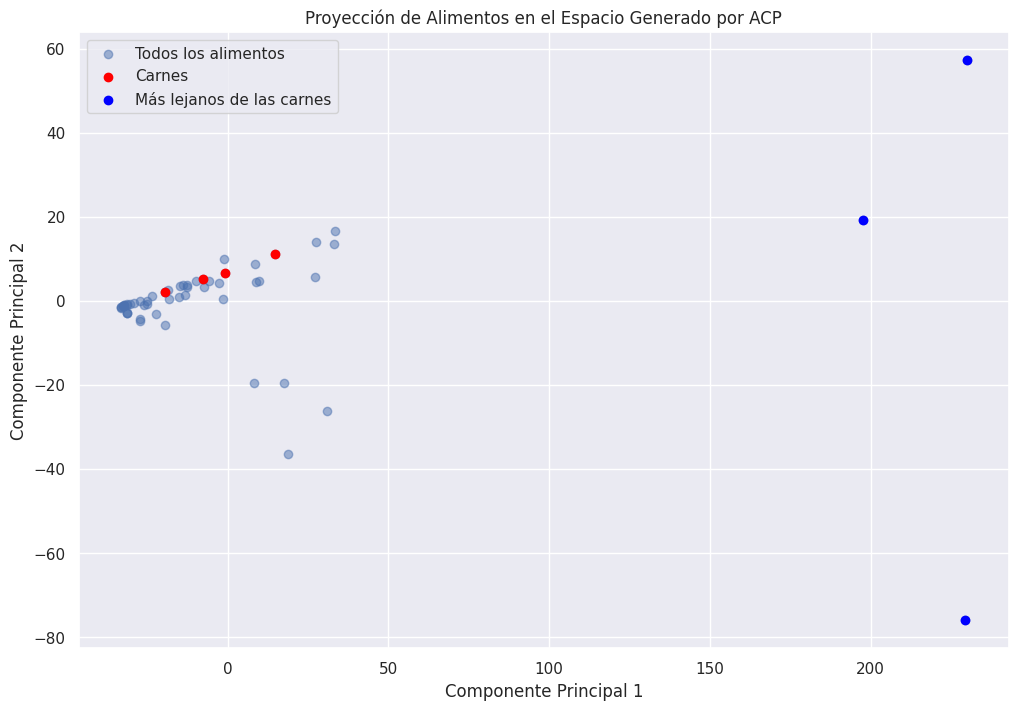

In [56]:

carnes_index = ['asado','bola de lomo','carne picada','paleta']

# Identificamos  y guardamos los índices de las carnes
indices_carnes = [i for i, alimento in enumerate(alimentos) if alimento.strip().lower() in carnes_index]

# Calculamos el centroide de las carnes en el espacio proyectado
centroide_carnes = np.mean(X_proyectado[indices_carnes], axis=0)

# Calculamos la distancia euclidiana de cada punto al centroide de las carnes
distancias_al_centroide = np.linalg.norm(X_proyectado - centroide_carnes, axis=1)

# Ordenamos los índices por distancia descendente y seleccionamos los más lejanos
num_puntos_lejanos = 3 # Número de puntos a seleccionar
indices_mas_lejanos = np.argsort(distancias_al_centroide)[-num_puntos_lejanos:]

# Obtenemos los alimentos más lejanos y sus distancias
alimentos_mas_lejanos = alimentos[indices_mas_lejanos]
distancias_mas_lejanos = distancias_al_centroide[indices_mas_lejanos]

print("Alimentos más lejanos de las carnes:")
for alimento, distancia in zip(alimentos_mas_lejanos, distancias_mas_lejanos):
    print(f"{alimento}: {distancia:.2f}")


plt.figure(figsize=(12, 8))
plt.scatter(X_proyectado[:, 0], X_proyectado[:, 1], alpha=0.5, label='Todos los alimentos')
plt.scatter(X_proyectado[indices_carnes, 0], X_proyectado[indices_carnes, 1], color='red', label='Carnes')
plt.scatter(X_proyectado[indices_mas_lejanos, 0], X_proyectado[indices_mas_lejanos, 1], color='blue', label='Más lejanos de las carnes')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección de Alimentos en el Espacio Generado por ACP')
plt.legend()
plt.grid(True)
plt.show()


Finalmente, vemos que los dos alimentos más alejados son: el pan frances y la leche fluida entera.

Veamos los valores nutricionales de estos alimentos para ver la compensación de la proteina perdida.

------------------------------------------------------------------------------

In [57]:
sustitutos = ['pan frances','leche fluida entera']

valores = nutricional_filtrada[nutricional_filtrada['Alimento'].isin(sustitutos)]

valores

,Alimento,Cantidad (gr/ml),HC (gr),Proteinas (gr),Grasas (gr),Na (gr),Ca (gr),Fe (gr),Azucares Libres (gr),AGS (gr),AGNI (gr),AG p (gr),Fibra (gr)
0,leche fluida entera,270.0,12.42,8.37,7.83,0.15390,0.28350,0.000189,0.0,4.99,2.19,0.52,0.00
26,pan frances,234.0,140.40,23.40,0.00,0.31824,0.04446,0.007790,0.0,0.00,0.00,0.00,6.32


Vemos en este caso, que la proteina perdida es posible compensarla en su totalidad con cantidades menores a las presentadas, por ejemplo consumiendo leche entera.

Necesitamos compensar 4.61 gramos de proteinas.

$$
\begin{array}{ccc}
8.37 \text{ gr de proteinas} & \rightarrow & 270 \text{ ml de Leche fluida entera} \\
4.61 \text{ gr de proteinas} & \rightarrow & X \text{ ml de Leche fluida entera} \\
\end{array}
$$


$$
X = \frac{4.61 \times 270}{8.37} = 148.70 \text{ ml de Leche Fluida Entera}
$$

De acuerdo a los calculados realizados, si se ingieren 148.70 ml más de los ingeridos según la tabla nutricional, se es posible cubrir la proteina perdida, sin embargo hay que tener en cuenta que se aportan carbohidratos, los cuales las carnes no aportan.